In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import json
import ast
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal
import requests

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict
        
def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX
            
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)
x2class = csv2dict('../data/assets/xgroup2/xgroup2class.csv')

In [3]:
rn2name = csv2dict('../data/assets/rn2name.csv')
rn2def = csv2dict('../data/assets/rn2def_versions.csv')

cpd2rn = csv2dict('../data/assets/cpd2rn.csv')
cpd2reac = csv2dict('../data/assets/cpd2reac.csv')
cpd2prod = csv2dict('../data/assets/cpd2prod.csv')
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

In [4]:
zpd2name = {}

with open('../data/assets/zcpd2name.txt', 'r') as file:
    lines = file.readlines()
    count = 1
    z = 0
    name = 0
    for line in lines:
        if count%2 == 1:  # odd
            z = line.strip()
        else:
            name = line.strip()
        zpd2name[z] = name
        count += 1   

In [5]:
# dict2csv(zpd2name, 'zpd2name.csv')

# figure 3B

In [6]:
# choose fastest run
batm = pd.read_pickle('../runs/2023-09-21_11-42-33_random_fold_ordering_42287-fixed-rn-seeds.pkl')
# file name is 'random' but it's actualy optimal

# new preATP run with peroxide-fix FASTEST run
# batm = pd.read_pickle('../data/fold_results/runs_fastest_slowest/2024-06-18_18-33-50.pkl.gz')

In [7]:
max(batm.folds_folditer.values())

371

In [8]:
max(batm.cpds_folditer.values())

361

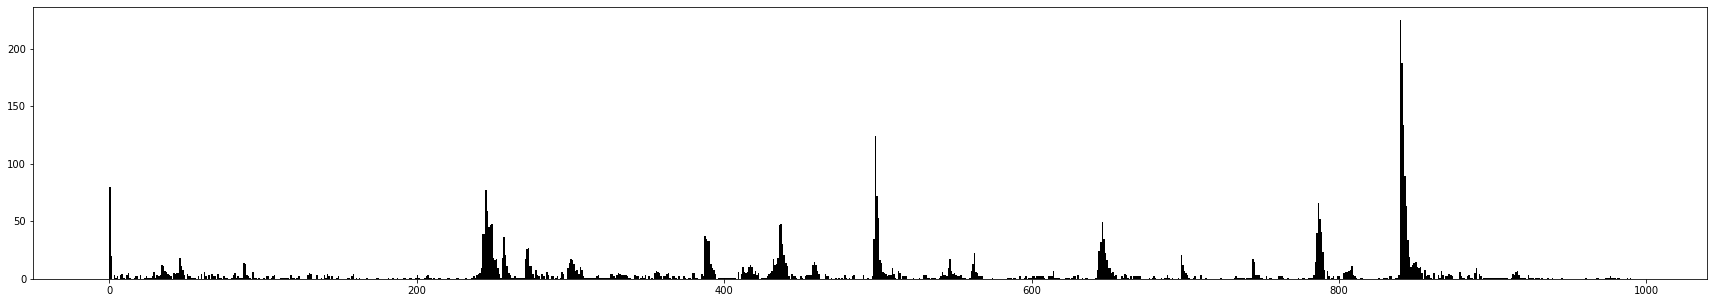

In [9]:
plt.figure(figsize=(30, 5))
plt.hist(batm.cpds_cumiter.values(), bins=1000, color='k')
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
folditer2cpd = {}
for c, order in batm.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

172


In [11]:
folditer2cpd.keys()

dict_keys([0, 1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 30, 31, 32, 37, 40, 42, 43, 44, 46, 47, 53, 55, 56, 57, 61, 66, 72, 74, 76, 79, 81, 82, 85, 86, 88, 92, 96, 100, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 116, 117, 118, 119, 120, 121, 122, 123, 124, 126, 127, 128, 130, 131, 132, 133, 134, 136, 137, 140, 141, 143, 144, 145, 146, 147, 148, 153, 155, 156, 157, 158, 162, 165, 167, 168, 170, 172, 178, 187, 188, 190, 191, 192, 194, 197, 198, 199, 201, 202, 207, 210, 211, 212, 217, 218, 221, 222, 223, 225, 226, 228, 231, 233, 242, 250, 252, 253, 255, 256, 260, 262, 268, 270, 272, 273, 275, 277, 279, 289, 291, 293, 295, 296, 298, 300, 301, 305, 306, 307, 308, 310, 311, 312, 313, 314, 315, 317, 321, 324, 329, 344, 350, 354, 356, 360, 361])

In [12]:
folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]

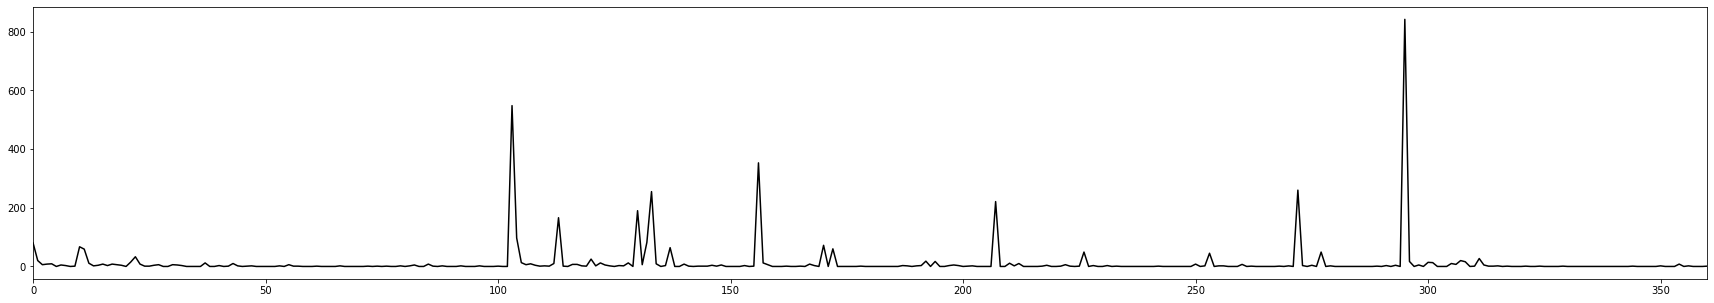

In [13]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

plt.xlim([0, 360])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

## try adding rugplot for multiple fold injections

In [14]:
folditer2folds = {}
for fold, folditer in batm.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)

In [15]:
folditer2folds

{0: ['fold_independent'],
 1: ['spontaneous'],
 2: ['2002'],
 3: ['1'],
 4: ['2487'],
 5: ['2006'],
 6: ['2003'],
 7: ['246'],
 8: ['7518'],
 9: ['62'],
 10: ['218'],
 11: ['2007'],
 12: ['304'],
 13: ['7525'],
 14: ['12'],
 15: ['11'],
 16: ['10'],
 17: ['109'],
 18: ['210'],
 19: ['7515'],
 20: ['279'],
 21: ['7577'],
 22: ['3016'],
 23: ['281'],
 24: ['7528'],
 25: ['331'],
 26: ['7542'],
 27: ['2011'],
 28: ['7572'],
 29: ['301'],
 30: ['282'],
 31: ['325'],
 32: ['206'],
 33: ['805'],
 34: ['7527'],
 35: ['7512'],
 36: ['180'],
 37: ['7560'],
 38: ['3691'],
 39: ['7529'],
 40: ['7579'],
 41: ['4126'],
 42: ['315'],
 43: ['205'],
 44: ['286'],
 45: ['70'],
 46: ['297'],
 47: ['4002'],
 48: ['2004'],
 49: ['7580'],
 50: ['7554'],
 51: ['2'],
 52: ['208'],
 53: ['247'],
 54: ['7571'],
 55: ['7561'],
 56: ['7567'],
 57: ['5'],
 58: ['7516'],
 59: ['7574'],
 60: ['7517'],
 61: ['307'],
 62: ['212'],
 63: ['7510'],
 64: ['5104'],
 65: ['387'],
 66: ['810'],
 67: ['3847'],
 68: ['2498'],

In [16]:
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

In [17]:
folditer2cpdNumFull.values()

dict_values([80, 20, 6, 8, 9, 0, 5, 3, 0, 1, 67, 59, 11, 2, 4, 8, 3, 8, 6, 4, 0, 15, 33, 8, 1, 1, 4, 6, 0, 0, 6, 5, 3, 0, 0, 0, 0, 12, 0, 0, 3, 0, 1, 10, 2, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 6, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 2, 0, 2, 5, 0, 0, 8, 1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 548, 97, 13, 6, 9, 4, 1, 2, 1, 10, 166, 1, 0, 7, 7, 2, 1, 25, 2, 12, 5, 2, 0, 3, 2, 12, 0, 190, 6, 82, 255, 9, 0, 3, 64, 0, 0, 8, 1, 0, 1, 1, 1, 4, 1, 5, 0, 0, 0, 0, 3, 0, 1, 353, 12, 6, 0, 0, 0, 1, 0, 0, 1, 0, 8, 3, 0, 72, 0, 60, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 2, 0, 2, 3, 18, 0, 17, 0, 0, 3, 5, 3, 0, 1, 2, 0, 0, 0, 0, 221, 0, 0, 11, 2, 10, 0, 0, 0, 0, 1, 4, 0, 0, 1, 6, 1, 0, 1, 49, 0, 3, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 8, 0, 2, 45, 0, 2, 2, 0, 0, 0, 7, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 0, 260, 3, 0, 4, 0, 49, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 4, 0, 842, 17, 0, 5, 0, 14, 13, 0, 0, 0, 10, 7, 20, 16, 0, 1, 27, 5

In [18]:
len(folditer2cpdNumFull)

361

In [19]:
for i in range(11):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0

In [20]:
len(folditer2cpdNumFull)

372

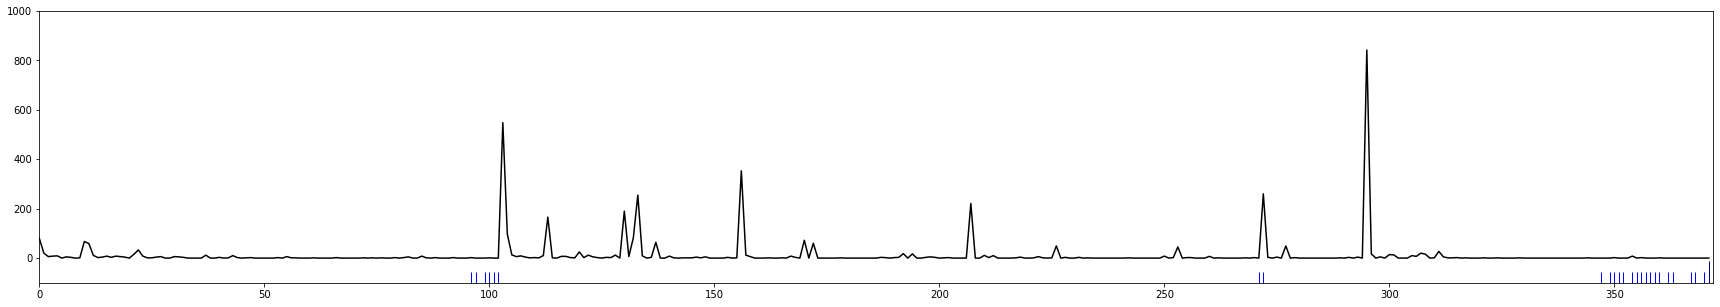

In [21]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Create a rugplot
# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection
sns.rugplot([371], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-100, 1000])
# plt.savefig('3B_cpds_rugplot2.svg', dpi=300, bbox_inches='tight')
plt.show()

## try re-scaling

In [22]:
rescale = []
for value in folditer2cpdNumFull.values():
    if value == 0:
        rescale.append(-50)
    else:
        rescale.append(value)

In [23]:
len(folditer2cpdNumFull.values())  # 0-360

372

In [24]:
len(folditer2folds.values())  # 0-371

372

In [25]:
for i in range(len(folditer2folds.values()) - len(folditer2cpdNumFull.values())):
    rescale.append(-50)

In [26]:
len(rescale)

372

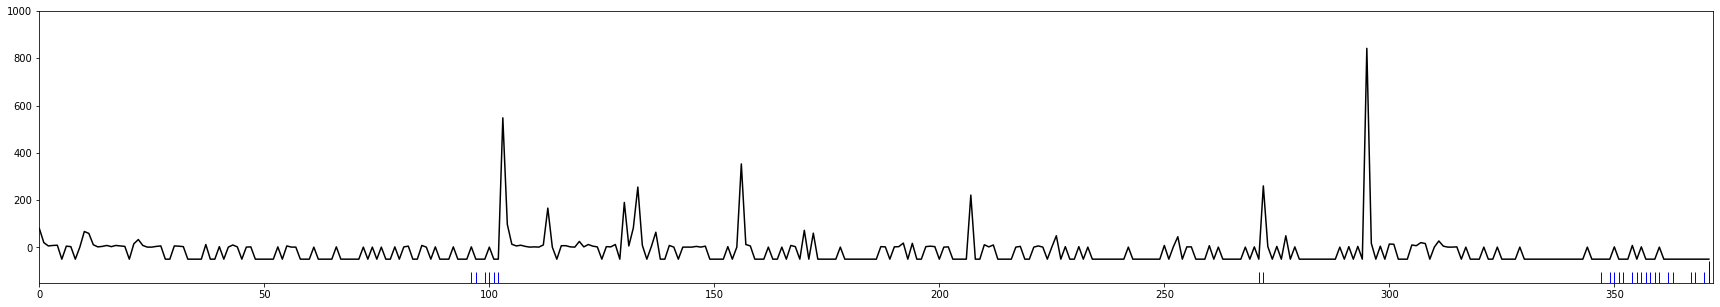

In [27]:
plt.figure(figsize=(30, 5))
plt.plot(rescale, color='k')

# Create a rugplot
# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection
sns.rugplot([371], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-150, 1000])
# plt.savefig('3B_cpds_rugplot_rescale2.svg', dpi=300, bbox_inches='tight')
plt.show()

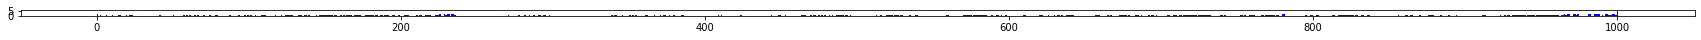

In [28]:
plt.figure(figsize=(30, 0.1))
plt.hist(batm.folds_cumiter.values(), bins=1000, edgecolor=None, color='blue')
# plt.savefig('3B_folds.png', dpi=300, bbox_inches='tight')
plt.show()

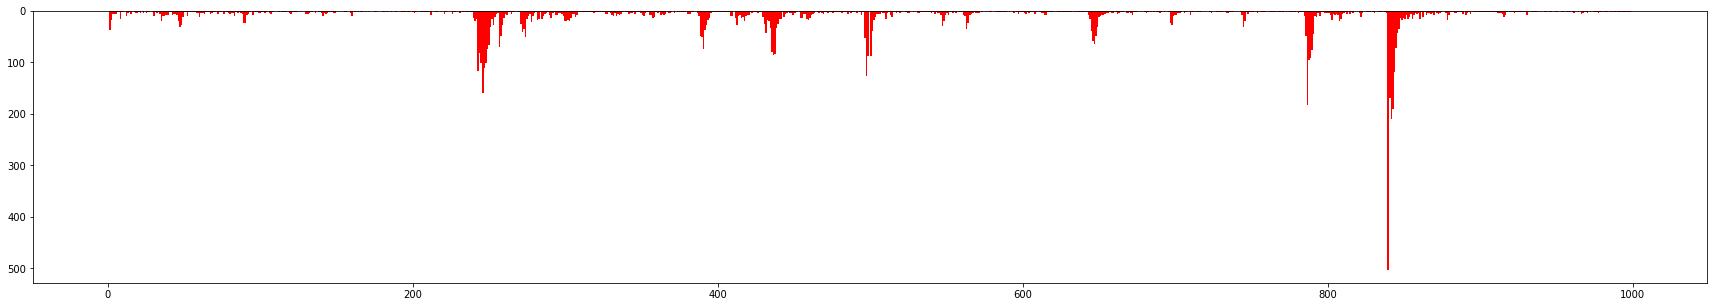

In [29]:
plt.figure(figsize=(30, 5))
plt.hist(batm.rns_cumiter.values(), bins=1000, edgecolor=None, color='red')
plt.gca().invert_yaxis()
# plt.savefig('3B_rns.png', dpi=300, bbox_inches='tight')
plt.show()

# annotate the peaks with folds & cpds

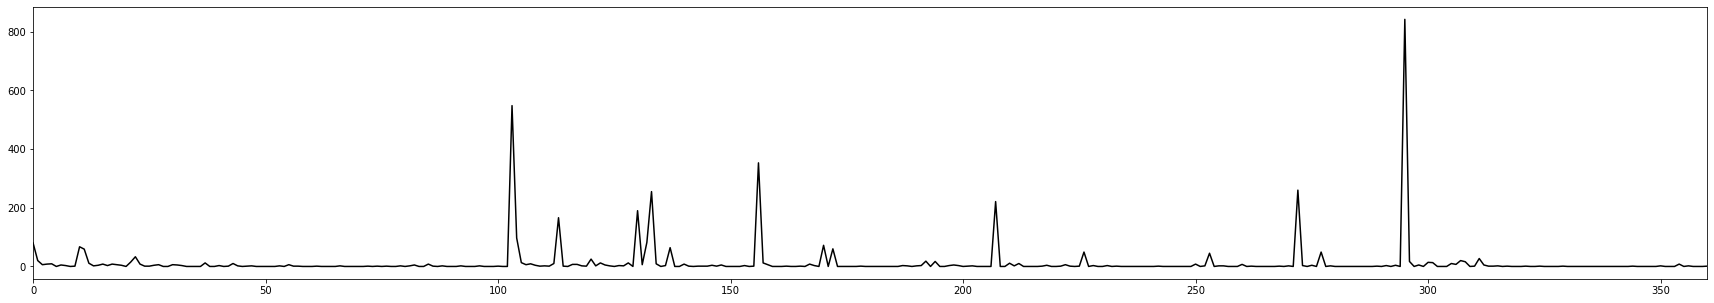

In [30]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')
plt.xlim([0, 360])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# get info about the big peaks

for folditer, num in folditer2cpdNumFull.items():
    if num > 100:
        print(folditer, num, folditer2folds[folditer])

103 548 ['4953']
113 166 ['7581']
130 190 ['323']
133 255 ['2492']
156 353 ['141']
207 221 ['875']
272 260 ['184', '7544']
295 842 ['3997']


In [32]:
folditer2rns = {}
for rn, i in batm.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)

In [33]:
folditer = 1
many = {}

for c in folditer2cpd[folditer]:
    
    try:
        print(len(cpd2rn[c]), len(set(cpd2rn[c]) & set([r for r in folditer2rns[folditer]])), c, cpd2name[c])

    except:
        print(f'      {c} {zpd2name[c]}')

1 1 C05723 Poly-gamma-D-glutamate
1 1 C03600 Carboxymethyloxysuccinate
2 2 C03248 Acetylenedicarboxylate
1 1 C03079 4-Hydroxy-L-glutamate
      Z00039 Pyruvoyl
2 1 C01883 Acetic ester
8 1 C05379 Oxalosuccinate
7 1 C05684 Selenite
1 1 C01990 3-Oxalomalate
11 2 C01563 Carbamate
      Z00043 Selenide
5 4 C03961 erythro-3-Hydroxy-Ls-aspartate
1 1 C00375 RCH2NH2
1 1 C06029 L-threo-3-Methylmalate
      Z00026 K (Potassium)
9 1 C02218 Dehydroalanine
3 3 C03981 2-Hydroxyethylenedicarboxylate
4 1 C02614 (S)-2-Methylmalate
      Z00042 Selenium
11 2 C05167 alpha-Amino acid


# when does cpd appear?

In [34]:
# from vanilla Leave-One-Out cofactors:

for cpd in ['C00018', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00061', 'C00007', 'C00027', 'C00229']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))

11 C00018 Pyridoxal phosphate 15
103 C00002 ATP 796
103 C00003 NAD+ 1078
103 C00010 CoA 638
103 C00024 Acetyl-CoA 218
113 C00129 Isopentenyl diphosphate 50
130 C00068 Thiamin diphosphate 28
133 C00061 FMN 72
295 C00007 Oxygen 1638
170 C00027 Hydrogen peroxide 333
272 C00229 Acyl-carrier protein 91


In [35]:
# from PCA: SAM, FAD, Cobalamin

for cpd in ['C00019', 'C00016', 'C00194']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c])

130 C00019 S-Adenosyl-L-methionine
133 C00016 FAD
194 C00194 Cobamide coenzyme


In [36]:
# compounds in other peaks

# 156:
    # 63 49 C00353 Geranylgeranyl diphosphate
    # 52 36 C00341 Geranyl diphosphate
    # 129 120 C00448 trans,trans-Farnesyl diphosphate
    # 28 26 C11901 Copalyl diphosphate

# 207:
    # no clear winner? except lots of aromatic AAs?
    # this peak also shifts a lot

# 272:
    # 94 53 C00229 Acyl-carrier protein
    # 40 21 C00078 L-Tryptophan
    # 23 21 C01209 Malonyl-[acyl-carrier protein]
    # 66 36 C00463 Indole
    # 60 28 C00125 Ferricytochrome c
    # 60 28 C00126 Ferrocytochrome c
    # 128 33 C00923 Ferricytochrome

In [37]:
# folds

# 103 548 ['4953'] purine (ATP, NADH, CoA)
# 113 166 ['7581'] Isopentenyl diphosphate
# 130 190 ['323']  SAM & ThPP

# 133 255 ['2492'] M00911: Riboflavin biosynthesis, plants and bacteria, GTP => riboflavin/FMN/FAD
                 # M00125: Riboflavin biosynthesis, plants and bacteria, GTP => riboflavin/FMN/FAD
# 156 353 ['141'] terpinoids
# 207 221 ['875'] M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
                # chorismate => Tyrosine, Phenylalanine, (Tryptophan), Menaquinone, Phylloquinone, Pyocyanine
# 272 260 ['184', '7544'] M00023 Tryptophan biosynthesis, chorismate => tryptophan

## rn2module

In [38]:
rn2modules = csv2dict('../data/assets/rn2modules.csv')
module2name = csv2dict('../data/assets/module2name.csv')

rn2maps = csv2dict('../data/assets/rn2maps.csv')
map2name = csv2dict('../data/assets/map2name.csv')
x2modules = csv2dict('../data/assets/xgroup2/xgroup2modules.csv')

In [39]:
myList = ['R04209', 'R07405', 'R04591', 'R01557']

In [40]:
for rn in myList:
    print(rn, rn2rules[rn])

R04209 {frozenset({'2003', '2007', '325', '206'}), frozenset({'2007', '206'})}
R07405 {frozenset({'2007'})}
R04591 {frozenset({'2003', '206', '325'}), frozenset({'206'}), frozenset({'2007', '206'})}
R01557 {frozenset({'12', '2002', '206'})}


In [41]:
rn2def['R04209']

'1-(5-Phospho-D-ribosyl)-5-amino-4-imidazolecarboxylate <=> Aminoimidazole ribotide + CO2'

In [42]:
rn2def['R07405']

'5-Carboxyamino-1-(5-phospho-D-ribosyl)imidazole <=> 1-(5-Phospho-D-ribosyl)-5-amino-4-imidazolecarboxylate'

In [43]:
rn2def['R04591']

"ATP + 1-(5-Phospho-D-ribosyl)-5-amino-4-imidazolecarboxylate + L-Aspartate <=> ADP + Orthophosphate + 1-(5'-Phosphoribosyl)-5-amino-4-(N-succinocarboxamide)-imidazole"

In [44]:
rn2def['R01557']

'Maltose <=> alpha,alpha-Trehalose'

In [45]:
rn2def['R11101']

'2-Aminobut-2-enoate <=> 2-Iminobutanoate'

In [46]:
rn2def['R00996']

'L-Threonine <=> 2-Oxobutanoate + Ammonia'

In [47]:
rn2def['R11098']

'2-Iminobutanoate + H2O <=> 2-Oxobutanoate + Ammonia'

In [48]:
rn2def['R04269']

'L-threo-3-Methylaspartate + 2-Oxoglutarate <=> Methyloxaloacetate + L-Glutamate'

In [49]:
rn2def['R08637']

'2-Aminobut-2-enoate + H2O <=> 2-Oxobutanoate + Ammonia'

In [50]:
for c in folditer2cpd[0]:
    print(c, cpd2name.get(c, 0))

C00001 H2O
C00417 cis-Aconitate
C00023 Iron
C01528 Hydrogen selenide
C00042 Succinate
C06232 Molybdate
Z00062 Vanadium
C00025 L-Glutamate
C00282 Hydrogen
C00034 Manganese
C17023 Sulfur donor
C00305 Magnesium cation
Z00002 4Fe4S
C00050 Metal
C00183 L-Valine
C00041 L-Alanine
C01127 4-Hydroxy-2-oxoglutarate
C14818 Fe2+
Z00067 3Fe4S
C00012 Peptide
C01732 Mesaconate
C00009 Orthophosphate
Z00069 Divalent Metal (M2)
Z00054 Zinc
C00123 L-Leucine
C00038 Zinc cation
C00071 Aldehyde
Z00006 Cobalt
C00014 Ammonia
C00311 Isocitrate
C00150 Molybdenum
C00065 L-Serine
C00209 Oxalate
C22155 [Fe-S] cluster scaffold protein
C00383 Malonate
C00148 L-Proline
C20679 Tungstate
C00048 Glyoxylate
Z00033 Sodium
C01335 ROH
C00080 H+
C00205 hn
C00407 L-Isoleucine
C00011 CO2
C00037 Glycine
C00030 Reduced acceptor
Z00020 Generic FeS Cluster
Z00070 Copper
C00188 L-Threonine
C00033 Acetate
C00175 Cobalt ion
Z00034 Nickel
C00028 Acceptor
C00049 L-Aspartate
Z00030 Mn
C00161 2-Oxo acid
C00238 Potassium cation
C00283 Hydr

In [51]:
maps = {}
modules = {}

folditer = 221

for r in folditer2rns[folditer]:
    print(r[:6], rn2def.get(r[:6], 0), rn2modules.get(r[:6],  ''), rn2maps.get(r[:6],  ''))  # keep the [:6] 
    
    for mod in rn2modules.get(r[:6],  ''):
        if mod not in modules:
            modules[mod] = 1
        else:
            modules[mod] += 1
            
    for mapname in rn2maps.get(r[:6],  ''):
        if mapname not in maps:
            maps[mapname] = 1
        else:
            maps[mapname] += 1

R12698 Dihydro-heme d1 + Acceptor <=> Heme d1 + Reduced acceptor  ['map00860']


In [52]:
'R12698' in x2rn['107']

True

In [53]:
for fold in folditer2folds[folditer]:
    print(fold, x2modules[fold])

107 ['M00154', 'M00529', 'M00155', 'M00156', 'M00595', 'M00973', 'M00622']


In [54]:
for mod, i in modules.items():
    print(mod, i, module2name[mod])

In [55]:
for mod in set(x2modules[fold]) & set(modules.keys()):
    print(mod, modules[mod], module2name[mod])

In [56]:
for m, i in maps.items():
    print(m, i, map2name[m])

map00860 1 Porphyrin metabolism


## try other runs

In [57]:
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')
batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3142.pkl.gz')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3143.pkl.gz')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3144.pkl.gz')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3145.pkl.gz')

In [58]:
folditer2cpd2 = {}
for c, order in batm2.cpds_folditer.items():
    if order not in folditer2cpd2.keys():
        folditer2cpd2[order] = [c]
    else:
        folditer2cpd2[order].append(c)
print(len(folditer2cpd2))

171


In [59]:
folditer2cpdNum2 = {}
for fold in folditer2cpd2.keys():
    folditer2cpdNum2[fold] = len(folditer2cpd2[fold])

folditer2cpdNumFull2 = {}
for i in range(0, max(folditer2cpd2.keys())):
    if i not in folditer2cpdNum2.keys():
        folditer2cpdNumFull2[i] = 0
    else:
        folditer2cpdNumFull2[i] = folditer2cpdNum2[i]

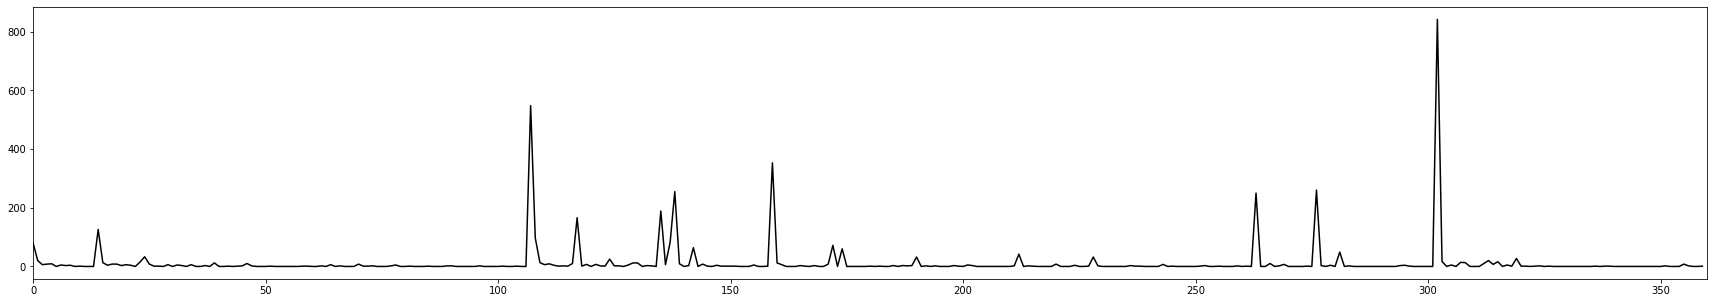

In [60]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull2.values(), color='k')
plt.xlim([0, 360])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
folditer2folds2 = {}
for fold, folditer in batm2.folds_folditer.items():
    if folditer not in folditer2folds2.keys():
        folditer2folds2[folditer] = [fold]
    else:
        folditer2folds2[folditer].append(fold)

In [62]:
for folditer, num in folditer2cpdNumFull2.items():
    if num > 100:
        print(f"{folditer} n={num}, {folditer2folds[folditer]}")

14 n=126, ['12']
107 n=548, ['129']
117 n=166, ['3692']
135 n=189, ['7514']
138 n=255, ['217']
159 n=353, ['601']
263 n=250, ['842']
276 n=260, ['4033']
302 n=842, ['7']


In [63]:
for cpd in ['C00018', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00015', 'C00029', 'C00061', 'C00007']:
    for folditer in folditer2cpd2.keys():
        for c in folditer2cpd2[folditer]:
            if c == cpd:
                print(folditer, c, len(cpd2rn[c]), cpd2name[c])

14 C00018 15 Pyridoxal phosphate
107 C00002 796 ATP
107 C00003 1078 NAD+
107 C00010 638 CoA
107 C00024 218 Acetyl-CoA
117 C00129 50 Isopentenyl diphosphate
135 C00068 28 Thiamin diphosphate
135 C00019 564 S-Adenosyl-L-methionine
138 C00015 399 UDP
138 C00029 195 UDP-glucose
138 C00061 72 FMN
302 C00007 1638 Oxygen


In [64]:
folditer2rns2 = {}
for rn, i in batm2.rns_folditer.items():
    if i not in folditer2rns2.keys():
        folditer2rns2[i] = []
    folditer2rns2[i].append(rn)

In [65]:
folditer2cpd2.keys()

dict_keys([0, 1, 2, 3, 4, 6, 7, 8, 10, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 29, 31, 32, 34, 37, 39, 42, 44, 45, 46, 47, 51, 58, 59, 62, 64, 66, 70, 71, 72, 73, 77, 78, 81, 85, 89, 90, 96, 101, 104, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 128, 129, 130, 132, 133, 135, 136, 137, 138, 139, 141, 142, 144, 145, 147, 148, 149, 150, 151, 155, 158, 159, 160, 161, 165, 166, 168, 171, 172, 174, 180, 182, 185, 187, 188, 189, 190, 192, 194, 198, 199, 201, 202, 211, 212, 214, 215, 220, 224, 227, 228, 229, 236, 237, 238, 243, 245, 251, 252, 255, 259, 261, 263, 266, 268, 269, 274, 276, 277, 279, 281, 283, 294, 295, 296, 302, 303, 305, 307, 308, 312, 313, 314, 315, 317, 318, 319, 320, 321, 323, 324, 326, 336, 338, 339, 351, 355, 356, 359, 360])

In [66]:
folditer = 274

for c in folditer2cpd2[folditer]:
    try:
        print(len(cpd2rn[c]), len(set(cpd2rn[c]) & set([r for r in folditer2rns2[folditer]])), c, cpd2name[c])

    except:
        print(f'      {c} {zpd2name[c]}')

1 1 C22339 Heme d1


# look at cpds that show up in many reactions

In [67]:
super_reactants = []

for c in cpd2reac.keys():
    if len(cpd2reac[c]) > 50:
        print(c, cpd2name[c], len(cpd2reac[c]))
        super_reactants.append(c)

C00001 H2O 1369
C00002 ATP 100
C00003 NAD+ 127
C00004 NADH 944
C00005 NADPH 894
C00006 NADP+ 191
C00007 Oxygen 1638
C00008 ADP 504
C00009 Orthophosphate 518
C00010 CoA 392
C00011 CO2 397
C00013 Diphosphate 397
C00014 Ammonia 259
C00015 UDP 284
C00019 S-Adenosyl-L-methionine 110
C00020 AMP 204
C00021 S-Adenosyl-L-homocysteine 384
C00022 Pyruvate 119
C00024 Acetyl-CoA 76
C00025 L-Glutamate 133
C00026 2-Oxoglutarate 190
C00028 Acceptor 160
C00030 Reduced acceptor 72
C00031 D-Glucose 87
C00033 Acetate 95
C00035 GDP 62
C00037 Glycine 59
C00073 L-Methionine 84
C00080 H+ 2115
C00124 D-Galactose 62
C00138 Reduced ferredoxin 118
C00229 Acyl-carrier protein 62
C00341 Geranyl diphosphate 55
C00363 dTDP 68
C00448 trans,trans-Farnesyl diphosphate 122
C00999 Ferrocytochrome b5 58
C01352 FADH2 78
C01847 Reduced FMN 51
C03024 [Reduced NADPH---hemoprotein reductase] 127
C05198 5'-Deoxyadenosine 59


In [68]:
for cpd in super_reactants:
    for folditer in folditer2cpd2.keys():
        for c in folditer2cpd2[folditer]:
            if c == cpd:
                print(folditer, c, len(cpd2rn[c]), cpd2name[c])  

0 C00001 4240 H2O
107 C00002 796 ATP
107 C00003 1078 NAD+
107 C00004 1056 NADH
107 C00005 1080 NADPH
107 C00006 1084 NADP+
302 C00007 1638 Oxygen
107 C00008 570 ADP
0 C00009 815 Orthophosphate
107 C00010 638 CoA
0 C00011 775 CO2
2 C00013 842 Diphosphate
0 C00014 482 Ammonia
138 C00015 399 UDP
135 C00019 564 S-Adenosyl-L-methionine
107 C00020 304 AMP
107 C00021 480 S-Adenosyl-L-homocysteine
0 C00022 244 Pyruvate
107 C00024 218 Acetyl-CoA
0 C00025 223 L-Glutamate
0 C00026 295 2-Oxoglutarate
0 C00028 232 Acceptor
0 C00030 232 Reduced acceptor
14 C00031 117 D-Glucose
0 C00033 148 Acetate
107 C00035 77 GDP
0 C00037 101 Glycine
135 C00073 100 L-Methionine
0 C00080 2561 H+
107 C00124 75 D-Galactose
46 C00138 159 Reduced ferredoxin
276 C00229 91 Acyl-carrier protein
159 C00341 65 Geranyl diphosphate
142 C00363 75 dTDP
159 C00448 155 trans,trans-Farnesyl diphosphate
276 C00999 59 Ferrocytochrome b5
138 C01352 82 FADH2
138 C01847 58 Reduced FMN
276 C03024 128 [Reduced NADPH---hemoprotein reducta

# fold annotation

In [69]:
# first 10 folds, ferredoxin (X187), P-loop (X2004), X3997, 
# HUP (X2005), HAD(X2006), Nat/Ivy (X213), CLB (X1), Beta-Grasp (X221), a/b-plaits (X304)
myFolds = ['1', '187', '2004', '2006', '3997', '213', '221', '304']
first10 = ['325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952']

In [70]:
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

In [71]:
first102iter = {}
for x in first10:
    print(f"X{x}: {batm.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    first102iter[x] = batm.folds_folditer[x]

X325: 31 alpha/beta-Hammerhead/Barrel-sandwich hybrid
X2002: 2 TIM beta/alpha-barrel
X218: 10 Enolase-N/ribosomal protein
X206: 32 no X name
X4953: 103 no X name
X2003: 6 Rossmann-like
X2007: 11 Flavodoxin-like
X602: 102 L-aspartase middle domain-like
X2005: 92 HUP domain-like
X4952: 102 no X name


In [72]:
myFolds2iter = {}
for x in myFolds:
    print(f"X{x}: {batm.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    myFolds2iter[x] = batm.folds_folditer[x]

X1: 3 cradle loop barrel
X187: 148 alpha-helical ferredoxin-like
X2004: 48 P-loop domains-like
X2006: 5 HAD domain-like
X3997: 295 no X name
X213: 111 Nat/Ivy
X221: 106 beta-Grasp
X304: 12 Alpha-beta plaits


In [73]:
import random

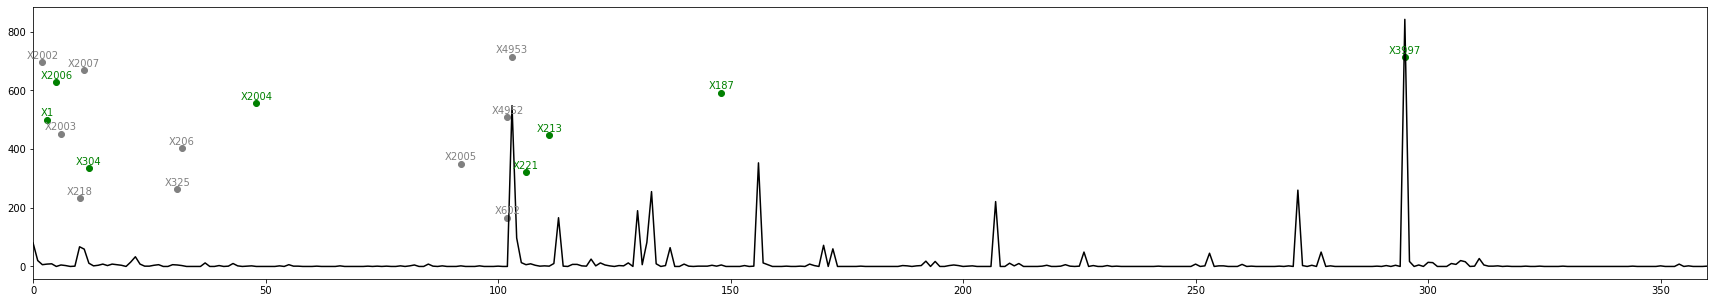

In [74]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in first102iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='gray')
    plt.scatter(value, position-5, color='gray')
for key, value in myFolds2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

In [75]:
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [76]:
group12iter = {}
for x in group1:
    print(f"X{x}: {batm.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    group12iter[x] = batm.folds_folditer[x]

X109: 17 Repetitive alpha hairpins
X2002: 2 TIM beta/alpha-barrel
X327: 147 Alpha-lytic protease prodomain-like
X2007: 11 Flavodoxin-like
X2004: 48 P-loop domains-like
X3997: 295 no X name
X875: 207 no X name
X304: 12 Alpha-beta plaits
X4953: 103 no X name
X7501: 132 no X name
X297: 46 no X name
X253: 253 no X name
X2486: 112 no X name
X1: 3 cradle loop barrel
X148: 291 Histone-like
X2003: 6 Rossmann-like
X2492: 133 no X name
X7584: 226 no X name
X328: 94 IF3-like
X325: 31 alpha/beta-Hammerhead/Barrel-sandwich hybrid
X212: 62 no X name
X3016: 22 no X name
X4011: 225 no X name
X2005: 92 HUP domain-like
X184: 272 no X name
X7579: 40 no X name
X4952: 102 no X name
X7523: 87 no X name
X218: 10 Enolase-N/ribosomal protein
X602: 102 L-aspartase middle domain-like
X101: 100 HTH
X330: 170 dsRBD-like
X206: 32 no X name
X141: 156 no X name
X7577: 21 no X name
X7544: 272 no X name
X7574: 59 no X name


In [77]:
class2color = {'beta':'blue', 'alpha':'red', 'a+b':'yellow', 'a/b':'green', 'mixed':'purple', 'other':'grey'}

In [78]:
x2class

{'1': 'beta',
 '2': 'beta',
 '220': 'beta',
 '236': 'beta',
 '239': 'beta',
 '264': 'beta',
 '270': 'beta',
 '271': 'beta',
 '290': 'beta',
 '3053': 'beta',
 '3083': 'beta',
 '3111': 'beta',
 '3112': 'beta',
 '3158': 'beta',
 '3174': 'beta',
 '3293': 'beta',
 '3335': 'beta',
 '3365': 'beta',
 '3372': 'beta',
 '3375': 'beta',
 '3385': 'beta',
 '3427': 'beta',
 '3445': 'beta',
 '3454': 'beta',
 '3497': 'beta',
 '3504': 'beta',
 '3534': 'beta',
 '3613': 'beta',
 '3665': 'beta',
 '4': 'beta',
 '4011': 'beta',
 '4027': 'beta',
 '4028': 'beta',
 '4056': 'beta',
 '4071': 'beta',
 '4087': 'beta',
 '4113': 'beta',
 '4184': 'beta',
 '4186': 'beta',
 '4200': 'beta',
 '4212': 'beta',
 '4237': 'beta',
 '4252': 'beta',
 '4291': 'beta',
 '4295': 'beta',
 '4315': 'beta',
 '4357': 'beta',
 '4972': 'beta',
 '4999': 'beta',
 '50': 'beta',
 '5084': 'beta',
 '517': 'beta',
 '55': 'beta',
 '58': 'beta',
 '60': 'beta',
 '6023': 'beta',
 '6047': 'beta',
 '6062': 'beta',
 '6073': 'beta',
 '6114': 'beta',
 '612

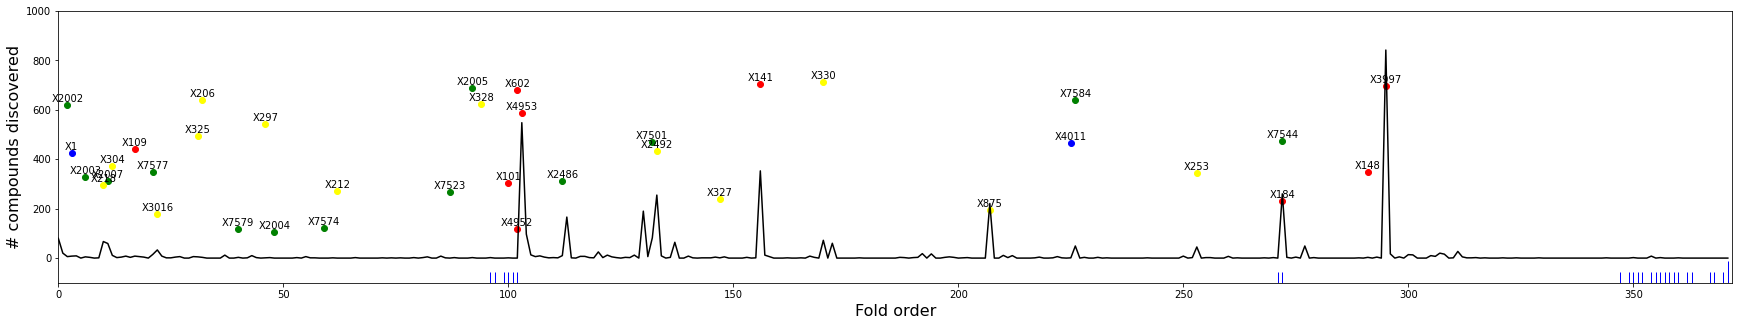

In [79]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='black')
    plt.scatter(value, position-5, color=class2color[x2class[key]])

# Add rugplot for multi-fold injections
double = []
triple = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double.append(i)
    if len(folds) == 3:
        triple.append(i)
sns.rugplot(double, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.ylabel('# compounds discovered', fontsize=16)
plt.xlabel('Fold order', fontsize=16)

# plt.savefig('3B_cpds_group1.svg', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

x_values = list(folditer2cpdNumFull.values())

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=400, title="folditer vs. #cpd")

# Add a line plot
p.line(range(len(x_values)), x_values, line_color="black")

# Add annotations
y_values = [random.randint(0, 200) for _ in range(len(group12iter.values()))]
source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
p.scatter('x', -5, source=source, size=5, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'folditer'
p.yaxis.axis_label = '# compounds discovered'
p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

NameError: name 'y_values' is not defined

In [ ]:
# folds

# 103 548 ['4953'] (G1) purine (ATP, NADH, CoA)
# 113 166 ['7581'] (G2) Isopentenyl diphosphate
# 130 190 ['323'] (G2) SAM & ThPP

# 133 255 ['2492'] (G1) M00911: Riboflavin biosynthesis, plants and bacteria, GTP => riboflavin/FMN/FAD
                      # M00125: Riboflavin biosynthesis, plants and bacteria, GTP => riboflavin/FMN/FAD
# 156 353 ['141'] (G1) terpinoids
# 207 221 ['875'] (G1) M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
                # chorismate => Tyrosine, Phenylalanine, (Tryptophan), Menaquinone, Phylloquinone, Pyocyanine
# 272 260 ['184', '7544'] (G1) M00023 Tryptophan biosynthesis, chorismate => tryptophan

In [ ]:
# X2486 (G1) for 112 
# X7501 (G1) for 132

## Check: medium-sized peaks + X2486 and X7501

In [ ]:
for folditer, num in folditer2cpdNumFull.items():
    if num > 30 and num < 100:
        print(folditer, num, folditer2folds[folditer])
    if folditer == 112 or folditer == 225:
        print(folditer, num, folditer2folds[folditer])

In [ ]:
# compounds:

# 10 67 ['218'] (G1) glycolysis
# 11 59 ['2007'] (G1) PLP
# 22 33 ['3016'] (G1) glutamate, homocysteine 
# 104 97 ['7524'] (G2) post-purine?
# 112 10 ['2486'] (G1) CoA derivatives?
# 132 82 ['7501'] (G1) Tetrahydrofolate
# 137 64 ['266'] (G2) dTDP metabolism
# 170 72 ['330'] (G1) Hydrogen peroxide, heme, Methylamine, Dimethylamine
# 172 60 ['296'] (G2) Sulfate, Sulfite, Thiosulfate, Taurine, Sulfoacetaldehyde, 3-Sulfolactate, Coenzyme M, 3'-Phosphoadenylyl sulfate 
# 226 49 ['7584'] (G1) menaquinol, phylloquinol
# 253 45 ['253'] (G1) L-Arginine, D-Arginine
# 277 49 ['4052'] (G2) Biotin

In [ ]:
folditer = 113

for c in folditer2cpd[folditer]:
    
    try:
        print(len(cpd2rn[c]), len(set(cpd2rn[c]) & set([r for r in folditer2rns[folditer]])), c, cpd2name[c])

    except:
        print(f'      {c} {zpd2name}')

In [ ]:
# folds:

# 10 67 ['218'] (G1) glycolysis, Entner-Doudoroff pathway, Gluconeogenesis
# 11 59 ['2007'] (G1) Pentose phosphate pathway
# 22 33 ['3016'] (G1) Cysteine and methionine metabolism; glutamate and GABA metabolism
# 104 97 ['7524'] (G2) post-purine? wide range of modules, many are AA-derivative
# 112 10 ['2486'] (G1) maps: Propanoate metabolism, Fatty acid elongation, Carbapenem biosynthesis
# 132 82 ['7501'] (G1) Tetrahydrofolate biosynthesis
# 137 64 ['266'] (G2) M00938 3 Pyrimidine deoxyribonucleotide biosynthesis, UDP => dTTP (=> dTDP metabolism)
# 170 72 ['330'] (G1) Heme, siroheme, cobalamin-precursor (cobyrinate)
# 172 60 ['296'] (G2) M00176 6 Assimilatory sulfate reduction, sulfate => H2S (=> Methanogenesis, Coenzyme M synth.)

# 225 1 ['4011'] (G1) map00130 Ubiquinone and other terpenoid-quinone biosynthesis (menaquinol, phylloquinol)
# 226 49 ['7584'] (G1) map00130: Ubiquinone and other terpenoid-quinone biosynthesis (menaquinol, phylloquinol)

# 253 45 ['253'] (G1) M00845 & M00844: Arginine biosynthesis
# 277 49 ['4052'] (G2) acetyl-CoA => pimeloyl-CoA => Biotin
    # M00036 2 Leucine degradation, leucine => acetoacetate + acetyl-CoA
    # M00540 5 Benzoate degradation, cyclohexanecarboxylic acid =>pimeloyl-CoA

# annotate cpds / cofactors

In [81]:
for c, name in cpd2name.items():
    if name.startswith('Phylloqui'):
        print(c, name)

C02059 Phylloquinone
C03313 Phylloquinol


In [ ]:
# 22 glutamate (C00302), GABA (C00334)
# 132 Tetrahydrofolate (C00101)
# 137 dTDP (C00363)

# 156 terpinoids
# 207 chorismate => Tyrosine, Phenylalanine

# 170 Hydrogen peroxide, heme, siroheme, cobyrinate (cobalamin-precursor)
# 172 H2S, Sulfate (C00059), Sulfite (C00094)
# 226 menaquinol, phylloquinol
# 253 L-Arginine (C00062), D-Arginine ()
# 272 Menaquinone, Phylloquinone, Tryptophan
# 277 pimeloyl-CoA (C01063), Biotin (C00120)

In [82]:
cpd2iter = {}

In [ ]:
# 272:
    # 94 53 C00229 Acyl-carrier protein
    # 40 21 C00078 L-Tryptophan
    # 23 21 C01209 Malonyl-[acyl-carrier protein]
    # 66 36 C00463 Indole
    # 60 28 C00125 Ferricytochrome c
    # 60 28 C00126 Ferrocytochrome c
    # 128 33 C00923 Ferricytochrome

In [83]:
for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iter[c] = folditer

156 C00448 trans,trans-Farnesyl diphosphate 155
156 C11901 Copalyl diphosphate 11
156 C00341 Geranyl diphosphate 65
156 C00353 Geranylgeranyl diphosphate 62
272 C00923 Ferricytochrome 5
272 C00463 Indole 8
272 C00229 Acyl-carrier protein 91
226 C05819 Menaquinol 12
226 C03313 Phylloquinol 7


In [84]:
for cpd in ['C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iter[c] = folditer

170 C00027 Hydrogen peroxide 333
170 C00032 Heme 18
172 C00059 Sulfate 37
172 C00094 Sulfite 47
192 C05773 Cobyrinate 5
207 C00251 Chorismate 13
207 C00082 L-Tyrosine 44
207 C00079 L-Phenylalanine 32
272 C00078 L-Tryptophan 36
272 C02059 Phylloquinone 6
272 C00828 Menaquinone 12
277 C01063 Pimeloyl-CoA 4
277 C00120 Biotin 11


In [85]:
for cpd in ['C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iter[c] = folditer

11 C00018 Pyridoxal phosphate 15
22 C00302 Glutamate 2
22 C00334 4-Aminobutanoate 16
103 C00002 ATP 796
103 C00003 NAD+ 1078
103 C00010 CoA 638
103 C00024 Acetyl-CoA 218
113 C00129 Isopentenyl diphosphate 50
130 C00068 Thiamin diphosphate 28
130 C00019 S-Adenosyl-L-methionine 564
132 C00101 Tetrahydrofolate 43
133 C00016 FAD 93
133 C00061 FMN 72
137 C00363 dTDP 75
194 C00194 Cobamide coenzyme 6
253 C00062 L-Arginine 50
295 C00007 Oxygen 1638


In [ ]:
len(folditer2cpdNumFull)

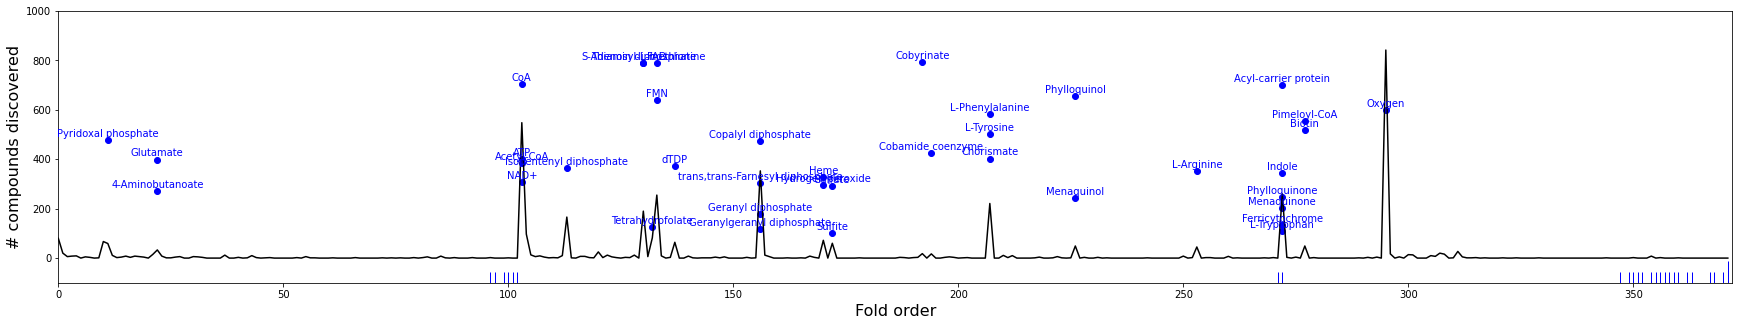

In [87]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Add rugplot for multi-fold injections
double = []
triple = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double.append(i)
    if len(folds) == 3:
        triple.append(i)
sns.rugplot(double, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.ylabel('# compounds discovered', fontsize=16)
plt.xlabel('Fold order', fontsize=16)
# plt.savefig('3B_cpds_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

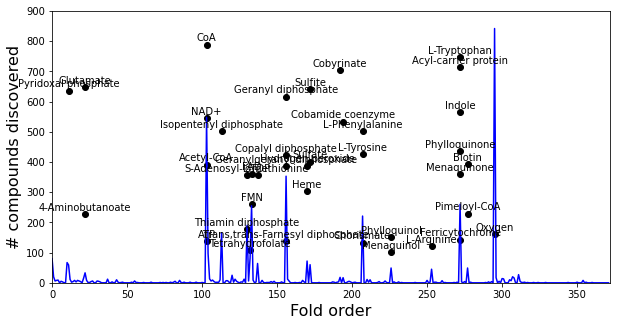

In [92]:
plt.figure(figsize=(10, 5))
plt.plot(folditer2cpdNumFull.values(), color='blue')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='k')
    plt.scatter(value, position-5, color='k')
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([0, 900])
plt.ylabel('# compounds discovered', fontsize=16)
plt.xlabel('Fold order', fontsize=16)
# plt.savefig('3B_cpds_annotated_short.svg', dpi=300, bbox_inches='tight')
plt.show()

# Amino acids & Nucleotides

In [95]:
aa = ['C00037', 'C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']
nuc = ['C00147', 'C00475', 'C00242', 'C00178', 'C00002', 'C00063', 'C00044', 'C00075', 'C00131', 'C00458', 'C00459', 'C00286']

In [96]:
cpd2iterAA = {}
cpd2iterNuc = {}

In [97]:
for cpd in aa:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterAA[c] = folditer
            
for cpd in nuc:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterNuc[c] = folditer

0 C00037 Glycine 101
104 C00077 L-Ornithine 25
0 C00041 L-Alanine 60
11 C00097 L-Cysteine 57
0 C00049 L-Aspartate 48
0 C00025 L-Glutamate 223
207 C00079 L-Phenylalanine 32
130 C00135 L-Histidine 29
0 C00407 L-Isoleucine 14
103 C00047 L-Lysine 42
0 C00123 L-Leucine 8
130 C00073 L-Methionine 100
18 C00152 L-Asparagine 10
0 C00148 L-Proline 18
11 C00064 L-Glutamine 53
253 C00062 L-Arginine 50
0 C00065 L-Serine 48
0 C00188 L-Threonine 14
0 C00183 L-Valine 11
272 C00078 L-Tryptophan 36
207 C00082 L-Tyrosine 44
103 C00147 Adenine 18
133 C00475 Cytidine 21
103 C00242 Guanine 7
137 C00178 Thymine 12
103 C00002 ATP 796
133 C00063 CTP 64
103 C00044 GTP 62
133 C00075 UTP 43
103 C00131 dATP 14
133 C00458 dCTP 8
137 C00459 dTTP 13
103 C00286 dGTP 10


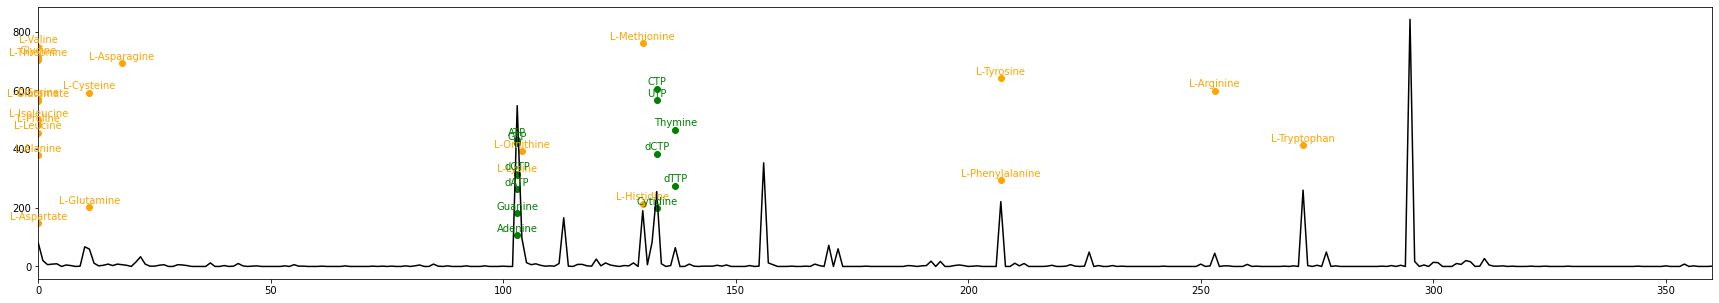

In [98]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iterAA.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')
for key, value in cpd2iterNuc.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_AA_Nuc.svg', dpi=300, bbox_inches='tight')
plt.show()

# Z cpds

In [99]:
cpd2iterZ = {}

for folditer in folditer2cpd.keys():
    for c in folditer2cpd[folditer]:
        if c.startswith('Z'):
            cpd2iterZ[c] = folditer

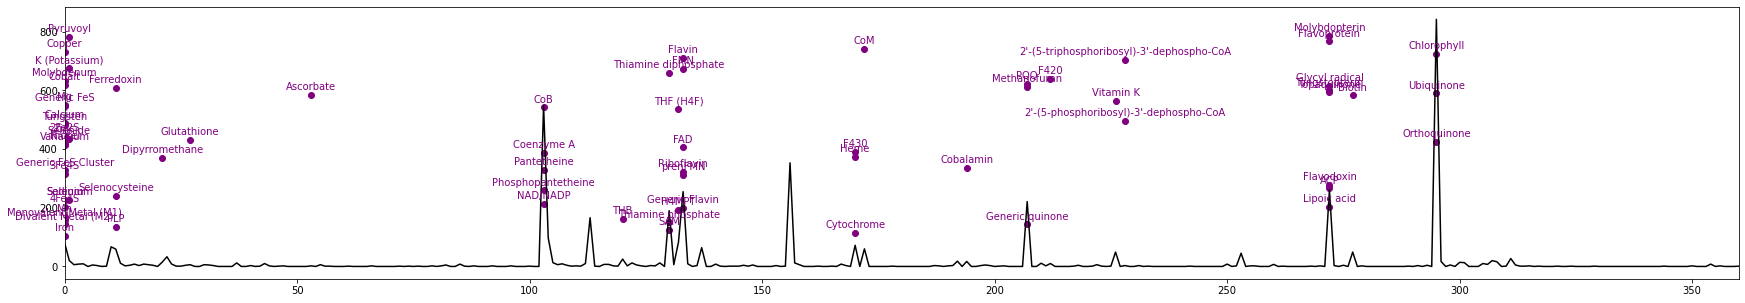

In [100]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iterZ.items():
    position = random.randint(100, 800)
    plt.text(value, position, zpd2name[key], ha='center', va='bottom', color='purple')
    plt.scatter(value, position-10, color='purple')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_Z.svg', dpi=300, bbox_inches='tight')
plt.show()

# vanilla cpd order

In [101]:
# vanilla = csv2dict('../vanilla_ne.csv')
# vanilla.pop('\ufeffCompound ID')

vanilla = csv2dict('../data/assets/vanilla_withAA.csv')

In [102]:
vanilla_iter2cpds = {}
for c, i in vanilla.items():
    if i not in vanilla_iter2cpds.keys():
        vanilla_iter2cpds[i] = [c]
    else:
        vanilla_iter2cpds[i].append(c)
        
vanilla_iter2cpdsNum = {}
for i in vanilla_iter2cpds.keys():
    vanilla_iter2cpdsNum[i] = len(vanilla_iter2cpds[i])

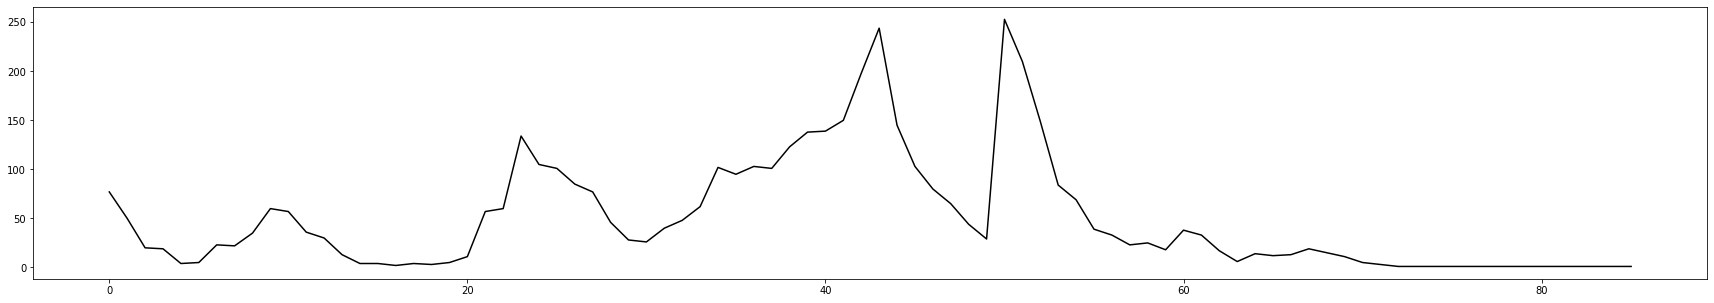

In [103]:
plt.figure(figsize=(30, 5))
plt.plot(vanilla_iter2cpdsNum.values(), color='k')
# plt.savefig('3B_cpds_vanilla.svg', dpi=300, bbox_inches='tight')
plt.show()

In [104]:
cpd2iter.keys()

dict_keys(['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007'])

In [105]:
vanilla_cpd2iter = {}
for c, i in vanilla.items():
    if c in cpd2iter.keys():
        vanilla_cpd2iter[c] = i

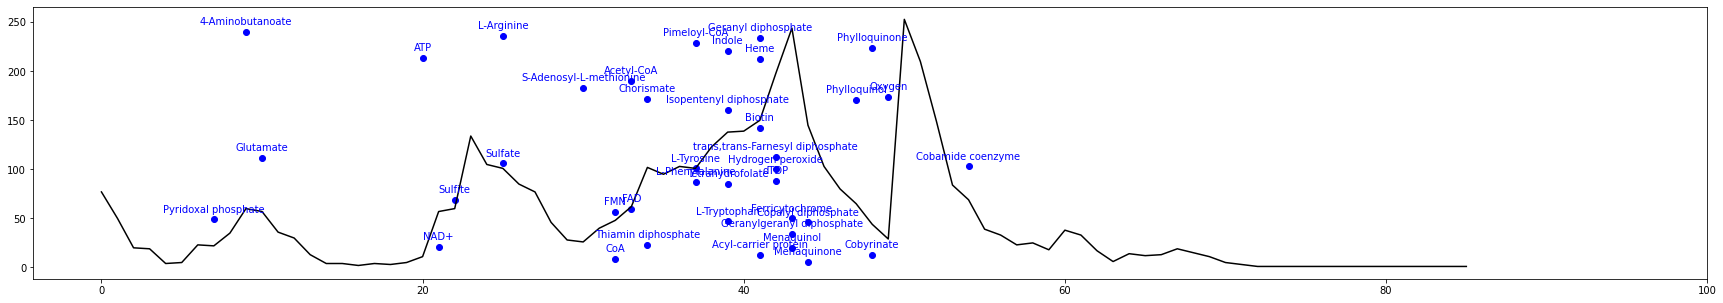

In [106]:
plt.figure(figsize=(30, 5))
plt.plot(vanilla_iter2cpdsNum.keys(), vanilla_iter2cpdsNum.values(), color='k')

# Add annotations
for key, value in vanilla_cpd2iter.items():
    y = random.randint(0, 250)
    x = value
    plt.text(x, y, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(x, y-5, color='b')

plt.xticks([0, 20, 40, 60, 80, 100])
# plt.savefig('3B_cpds_vanilla_withAA_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
vanilla_cpd2iterAA = {}
vanilla_cpd2iterNuc = {}

for c, i in vanilla.items():
    if c in cpd2iterAA.keys():
        vanilla_cpd2iterAA[c] = i
    if c in cpd2iterNuc.keys():
        vanilla_cpd2iterNuc[c] = i

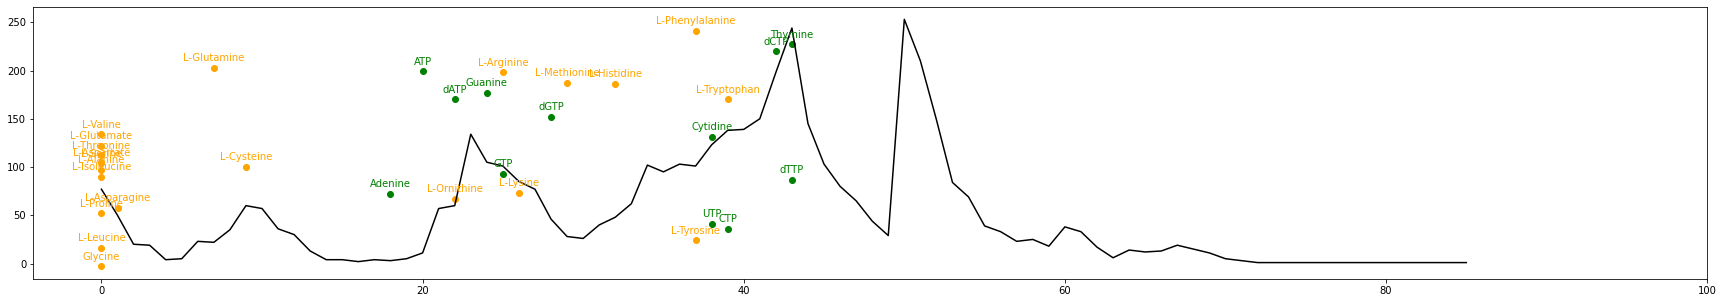

In [108]:
plt.figure(figsize=(30, 5))
plt.plot(vanilla_iter2cpdsNum.keys(), vanilla_iter2cpdsNum.values(), color='k')

# Add annotations
for key, value in vanilla_cpd2iterAA.items():
    y = random.randint(0, 250)
    x = value
    plt.text(x, y, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(x, y-5, color='orange')
for key, value in vanilla_cpd2iterNuc.items():
    y = random.randint(0, 250)
    x = value
    plt.text(x, y, cpd2name[key], ha='center', va='bottom', color='green')
    plt.scatter(x, y-5, color='green')

plt.xticks([0, 20, 40, 60, 80, 100])
# plt.savefig('3B_cpds_vanilla_withAA_AA_Nuc.svg', dpi=300, bbox_inches='tight')
plt.show()

# folds that don’t add new cpd when injected => what’s their LOO size?

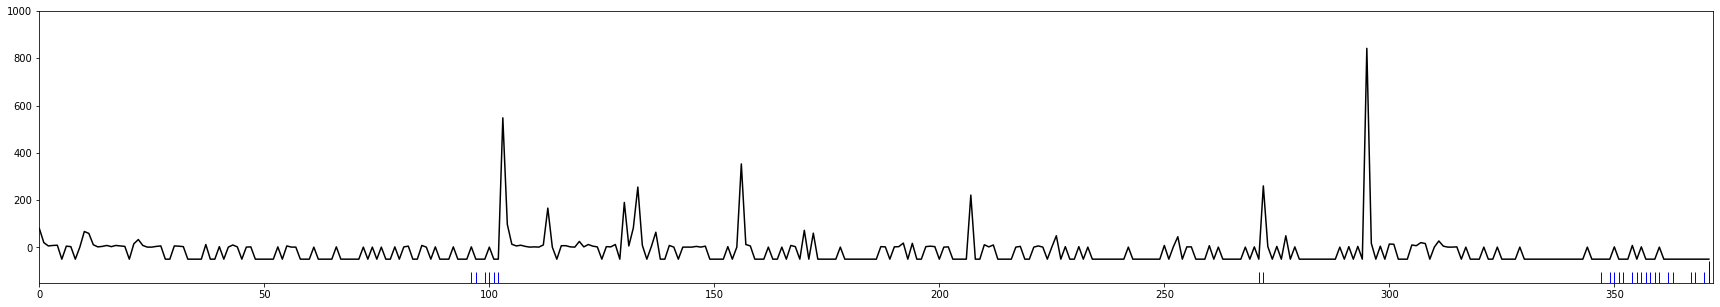

In [109]:
plt.figure(figsize=(30, 5))
plt.plot(rescale, color='k')

# Create a rugplot
# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection
sns.rugplot([371], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 372])
plt.ylim([-150, 1000])
plt.show()

In [110]:
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')  # peroxide fix => no X558

count = 0
for fo, num in folditer2cpdNumFull.items():
    if num == 0:
        count += 1
        print(fo, folditer2folds[fo], x2ns.get(folditer2folds[fo][0], 0))
count

5 ['2006'] 4272
8 ['7518'] 4291
20 ['279'] 4289
28 ['7572'] 4291
29 ['301'] 4275
33 ['805'] 4283
34 ['7527'] 4290
35 ['7512'] 4095
36 ['180'] 4262
38 ['3691'] 4291
39 ['7529'] 4290
41 ['4126'] 4291
45 ['70'] 4289
48 ['2004'] 2710
49 ['7580'] 4291
50 ['7554'] 4291
51 ['2'] 4291
52 ['208'] 4276
54 ['7571'] 4288
58 ['7516'] 4230
59 ['7574'] 3256
60 ['7517'] 4291
62 ['212'] 2815
63 ['7510'] 4259
64 ['5104'] 4291
65 ['387'] 4291
67 ['3847'] 4291
68 ['2498'] 4290
69 ['4081'] 4291
70 ['3651'] 4291
71 ['7520'] 4291
73 ['298'] 4195
75 ['164'] 4289
77 ['2484'] 4128
78 ['7541'] 4264
80 ['7573'] 3814
83 ['103'] 4254
84 ['302'] 4290
87 ['7523'] 2901
89 ['285'] 4291
90 ['64'] 4291
91 ['2485'] 4279
93 ['708'] 4291
94 ['328'] 2831
95 ['2493'] 4278
97 ['355', '4178'] 4291
98 ['108'] 4291
99 ['4018', '7587'] 4270
101 ['7546', '7507'] 4291
102 ['4952', '602'] 457
115 ['7504'] 4291
125 ['503'] 4291
129 ['7509'] 4291
135 ['7514'] 4280
138 ['217'] 4193
139 ['5084'] 4291
142 ['868'] 4291
149 ['133'] 4291
150

201

# "burst analysis"
Average #cpd discovered as a result of each fold injection => fold2cpdNum(Ave)

In [111]:
# cpds = pd.read_csv('../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_C00002.csv', index_col=0)
# folds = pd.read_csv('../folds_folditer_pre-expansion_1000runs_C00002.csv', index_col=0)

In [112]:
cpds = pd.read_csv('peroxide_cumiter_fix/peroxide_cumiter_fix_cpds_folditer_preATP.csv', index_col=0)
folds = pd.read_csv('peroxide_cumiter_fix/peroxide_cumiter_fix_folds_folditer_preATP.csv', index_col=0)

In [113]:
# map folditer2#cpds

i2cNum_1000runs = {}
for run in cpds.columns:
    i2c = {}
    for c, i in cpds[run].items():
        if i not in i2c.keys():
            i2c[i] = [c]
        else:
            i2c[i].append(c)
    i2cNum_1000runs[run] = {i:len(c) for i, c in i2c.items()}

In [114]:
fold2cpdNum_1000runs = {}
for run in folds.columns:
    fold2cpdNum = {}
    for fold, i in folds[run].items():  # fold2folditer
        fold2cpdNum[fold] = i2cNum_1000runs[run].get(i, 0)
    fold2cpdNum_1000runs[run] = fold2cpdNum

In [115]:
# empty dict with folds as keys
fold2cpdNum = {fold:[] for fold in folds.index}

for run in fold2cpdNum_1000runs:
    for fold, num in fold2cpdNum_1000runs[run].items():
        fold2cpdNum[fold].append(num)

for fold in fold2cpdNum.keys():
    fold2cpdNum[fold] = [np.mean(fold2cpdNum[fold]), np.std(fold2cpdNum[fold])]

fold2cpdNumMean = {fold:num[0] for fold, num in fold2cpdNum.items()}
fold2cpdNumStd = {fold:num[1] for fold, num in fold2cpdNum.items()}

In [116]:
stars = {}
for key, value in fold2cpdNumMean.items():
    if value > 50 and key != 'fold_independent':
        stars[key] = value
stars

{'2005': 232.0,
 '7581': 90.0,
 '3016': 60.0,
 '103': 117.0,
 '323': 129.81333333333333,
 '141': 289.73333333333335,
 '7501': 83.08,
 '2492': 291.6,
 '266': 68.0,
 '296': 60.0,
 '875': 200.14666666666668,
 '4052': 71.0,
 '4033': 71.0,
 '4953': 261.0,
 '602': 261.0,
 '3997': 847.0}

In [117]:
foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')

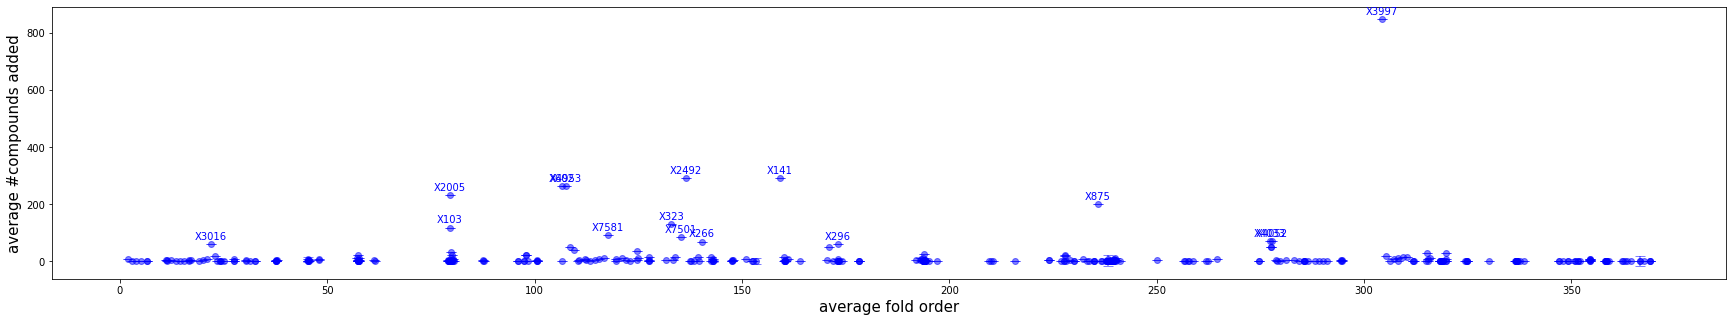

In [118]:
plt.figure(figsize=(30, 5))
valid_keys, data1, data2 = todata(foAveNONE, fold2cpdNumMean)
plt.errorbar(data1, data2, yerr=list(fold2cpdNumStd.values())[2:], fmt='o', color='b', alpha = 0.5, capsize=5)

# Add annotations
for key, value in stars.items():
    plt.text(foAveNONE[key], value+10, 'X'+str(key), ha='center', va='bottom', color='blue')

plt.xlabel('average fold order', fontsize=15)
plt.ylabel('average #compounds added', fontsize=15)
# plt.savefig('burst_analysis_ATP.svg')
plt.show()

## Leave one out size vs. burst size

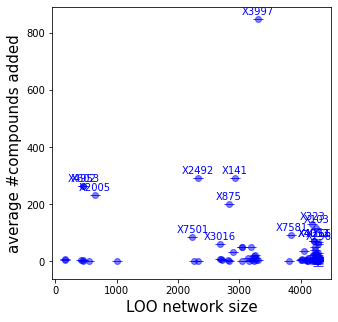

In [119]:
plt.figure(figsize=(5, 5))
valid_keys, data1, data2 = todata(x2ns, fold2cpdNumMean)
plt.errorbar(data1, data2, yerr=list(fold2cpdNumStd.values())[2:], fmt='o', color='b', alpha = 0.5, capsize=5)

# Add annotations
for key, value in stars.items():
    plt.text(x2ns[key], value+10, 'X'+str(key), ha='center', va='bottom', color='blue')

plt.xlabel('LOO network size', fontsize=15)
plt.ylabel('average #compounds added', fontsize=15)
# plt.savefig('burst_analysis_LOO_ATP.svg')
plt.show()

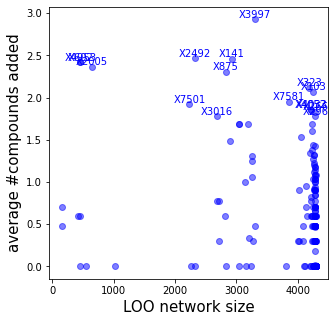

In [120]:
plt.figure(figsize=(5, 5))
valid_keys, data1, data2 = todata(x2ns, fold2cpdNumMean)
data2_no_zeros = np.where(np.array(data2) == 0, 1, data2)  # log(1) = 0
data2_no_negs = np.where(data2_no_zeros < 1, 1, data2_no_zeros)

# plt.errorbar(np.log10(data1), np.log10(data2_no_zeros), yerr=np.log10(list(fold2cpdNumStd.values())[2:]), fmt='o', color='b', alpha = 0.5, capsize=5)
plt.scatter(data1, np.log10(data2_no_negs), color='b', alpha = 0.5)

# Add annotations
for key, value in stars.items():
    plt.text(x2ns[key], np.log10(value), 'X'+str(key), ha='center', va='bottom', color='blue')

plt.xlabel('LOO network size', fontsize=15)
plt.ylabel('average #compounds added', fontsize=15)
# plt.savefig('burst_analysis_LOO_ATP_log.svg')
plt.show()

## burst size vs. reaction rule count

In [121]:
x2rulesNum_run = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_run.csv')
len(x2rulesNum_run)

396

In [122]:
for value in data2_no_zeros:
    if np.log10(value) < 0:
        print(value, np.log10(value))

0.20666666666666667 -0.6847295652214086
0.7933333333333333 -0.10054429766315048
0.26666666666666666 -0.5740312677277188


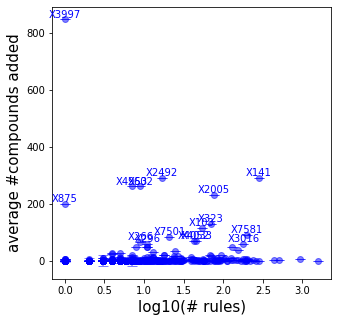

In [125]:
plt.figure(figsize=(5, 5))
valid_keys, data1, data2 = todata(x2rulesNum_run, fold2cpdNumMean)

plt.errorbar(np.log10(data1), data2, yerr=list(fold2cpdNumStd.values())[2:], fmt='o', color='b', alpha = 0.5, capsize=5)

# Add annotations
for key, value in stars.items():
    plt.text(np.log10(x2rulesNum_run[key]), value, 'X'+str(key), ha='center', va='bottom', color='blue')

plt.xlabel('log10(# rules)', fontsize=15)
plt.ylabel('average #compounds added', fontsize=15)
# plt.savefig('burst_analysis_rulesNum_loglog_ATP.svg')
plt.show()

In [ ]:
list(filter(lambda x: x<1, data2_no_zeros))

In [ ]:
0 in data1

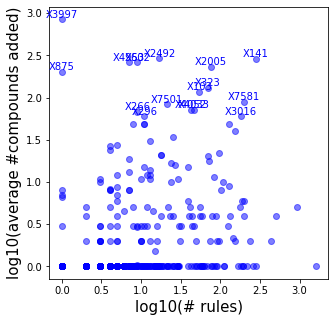

In [126]:
plt.figure(figsize=(5, 5))
valid_keys, data1, data2 = todata(x2rulesNum_run, fold2cpdNumMean)
data2_no_zeros = np.where(np.array(data2) == 0, 1, data2)  # log(1) = 0
data2_no_negs = np.where(data2_no_zeros < 1, 1, data2_no_zeros)

# plt.errorbar(np.log10(data1), np.log10(data2_no_zeros), yerr=np.log10(list(fold2cpdNumStd.values())[2:]), fmt='o', color='b', alpha = 0.5, capsize=5)
plt.scatter(np.log10(data1), np.log10(data2_no_negs), color='b', alpha = 0.5)


# Add annotations
for key, value in stars.items():
    plt.text(np.log10(x2rulesNum_run[key]), np.log10(value), 'X'+str(key), ha='center', va='bottom', color='blue')

plt.xlabel('log10(# rules)', fontsize=15)
plt.ylabel('log10(average #compounds added)', fontsize=15)
# plt.savefig('burst_analysis_rulesNum_loglog_ATP.svg')
plt.show()

In [181]:
def safeLog10(data_dict, small_constant=10**-0.00001):
    log10_dict = {}
    for key, value in data_dict.items():
        if value <= 0:
            log10_value = np.log10(small_constant)  # log10 of small constant if value is zero or negative
        elif value <= 1:
            log10_value = np.log10(round(value))
        else:
            log10_value = np.log10(value)
        log10_dict[key] = log10_value
    return log10_dict

In [179]:
fold2cpdNumMean['316']

0.20666666666666667

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_26588/1052577502.py:7: RuntimeWarning: divide by zero encountered in log10
  log10_value = np.log10(round(value))


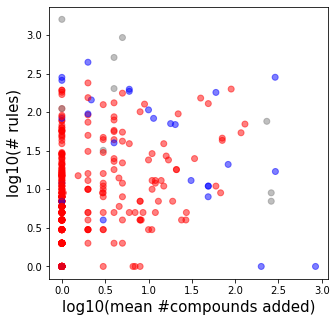

In [184]:
plt.figure(figsize=(5, 5))
dict1 = safeLog10(fold2cpdNumMean)
dict2 = safeLog10(x2rulesNum_run)

valid_keys, data1, data2 = todata(dict1, dict2)
# data2_no_zeros = np.where(np.array(data2) == 0, 1, data2)  # log(1) = 0
# data2_no_negs = np.where(data2_no_zeros < 1, 1, data2_no_zeros)

# plt.errorbar(np.log10(data1), np.log10(data2_no_zeros), yerr=np.log10(list(fold2cpdNumStd.values())[2:]), fmt='o', color='b', alpha = 0.5, capsize=5)
colors = ['gray' if key in first10 else ('b' if key in group1 else 'r') for key in valid_keys]
plt.scatter(data1, data2, color=colors, alpha = 0.5)


# Add annotations
# for key, value in stars.items():
#     plt.text(np.log10(value), np.log10(x2rulesNum_run[key]), 'X'+str(key), ha='center', va='bottom', color='blue')
# for fold in group1:
#     plt.text(dict1[fold], dict2[fold], 'X'+str(fold), ha='center', va='bottom', color='black')

plt.xlabel('log10(mean #compounds added)', fontsize=15)
plt.ylabel('log10(# rules)', fontsize=15)
# plt.savefig('burst_analysis_rulesNumRun_loglog_preATP.svg')
plt.show()